In [1]:
import scarf

scarf.configure_output(level="ERROR", progress=True)

repository = scarf.cytebase.connect('scarf_docs')
source_uri = (
    'hf://buckets/Nygen/cytebase/scarf_docs/'
    'tenx_5K_pbmc_rnaseq/data.zarr'
)

ds = scarf.DataStore(
    source_uri,
    zarr_mode='r',
    storage_options={'token': False},
    nthreads=4,
)
print(ds)

DataStore has 3940 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_leiden_cluster', 'RNA_UMAP1', 
            'RNA_G2M_score', 'RNA_S_score', 'RNA_cell_cycle_phase', 'RNA_doublet_score', 'RNA_UMAP2', 
            'RNA_nCounts', 'RNA_clusters', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'feature_type', 'nCells', 
            'dropOuts', 'genome', 'I__hvgs'


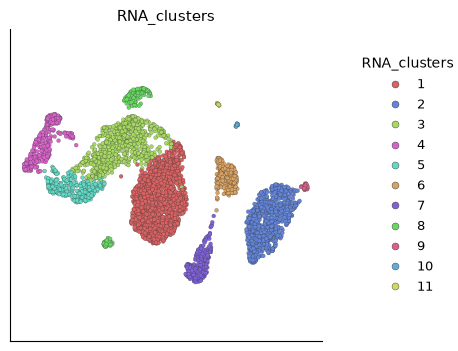

In [2]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_clusters',
)

In [3]:
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import matplotlib.pyplot as plt
import zarr

from scarf.tools.repack_zarr import repack_store

mount_directory = TemporaryDirectory()
staged_dataset = repository.download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination=mount_directory.name,
    zarr=True,
)
repacked_path = Path(mount_directory.name) / 'counts.zarr'
target_path = Path(mount_directory.name) / 'analysis.zarr'

repack_store(
    str(staged_dataset / 'data.zarr'),
    str(repacked_path),
    nthreads=2,
)

Downloading bucket files: 48357614 / 48357614 complete

Downloading bytes: 48357614 / 48357614 complete

Repacking RNA/artifacts/embedding//values: 1 / 1 complete

Repacking RNA/artifacts/dendrogram//data: 1 / 1 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

...

Repacking RNA/artifacts/cluster_hierarchy//children: 1 / 1 complete

Repacking RNA/artifacts/connectivity_map//edges: 1 / 1 complete

Repacking RNA/artifacts/embedding_initialization//cluster_centers: 1 / 1 complete

Repacking RNA/counts: 1 / 1 complete

  RNA/counts: shape=(5025, 33538), dtype=uint32, chunks=(5025, 4791), shards=(5025, 38328)


In [4]:
mounted = scarf.mount_datastore(
    str(repacked_path),
    at=str(target_path),
    default_assay='RNA',
    nthreads=4,
)

matrix_source = zarr.open_group(str(target_path), mode='r').attrs['matrixSource']
print('Target path:', target_path)
print('Target exists:', target_path.exists())
print('Remote demo URI:', source_uri)
print('Downloaded dataset:', staged_dataset)
print('Mounted count source:', matrix_source['location'])
print('Mounted assays:', sorted(matrix_source['assays']))

Target path: /tmp/tmpdfi6vbai/analysis.zarr
Target exists: True
Remote demo URI: hf://buckets/Nygen/cytebase/scarf_docs/tenx_5K_pbmc_rnaseq/data.zarr
Downloaded dataset: /tmp/tmpdfi6vbai/tenx_5K_pbmc_rnaseq
Mounted count source: /tmp/tmpdfi6vbai/counts.zarr
Mounted assays: ['RNA']


In [5]:
target_root = zarr.open_group(str(target_path), mode='r')

print('Counts stored in target:', 'counts' in target_root['RNA'])
print('Mounted shape:', mounted.RNA.rawData.shape)

Counts stored in target: False
Mounted shape: (5025, 33538)


In [6]:
cell_selection = mounted.snapshot_cell_selection(cell_key='I')
mounted_features = mounted.select_hvgs(
    cell_selection,
    min_cells=20,
    top_n=500,
    show_plot=False,
)
normalized = mounted.run_normalization(cell_selection, mounted_features)
pca = mounted.run_pca(normalized, dims=15)

initialization = mounted.build_embedding_initialization(pca)
ann_index = mounted.build_ann_index(pca)
neighbors = mounted.query_neighbors(ann_index, k=11)
graph = mounted.build_connectivity_map(neighbors)
mounted_umap = mounted.run_umap(
    graph,
    initialization,
    n_epochs=100,
    spread=5,
    min_dist=1,
    parallel=True,
)
mounted_clusters = mounted.run_leiden_clustering(
    graph,
    resolution=0.5,
)

Calculating feature statistics: 30 / 30 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 100 / 100 complete

In [7]:
mounted_umap_values = np.asarray(mounted.load_artifact(mounted_umap)['values'][:])
mounted_cluster_values = np.asarray(
    mounted.load_artifact(mounted_clusters)['values'][:]
)
plt.scatter(
    mounted_umap_values[:, 0],
    mounted_umap_values[:, 1],
    c=mounted_cluster_values,
    s=3,
)

In [8]:
target_bytes = sum(
    path.stat().st_size
    for path in target_path.rglob("*")
    if path.is_file()
)
logical_count_bytes = int(
    np.prod(mounted.RNA.rawData.shape)
    * mounted.RNA.rawData.dtype.itemsize
)
print("Writable target bytes:", target_bytes)
print("Dense logical count bytes:", logical_count_bytes)

Writable target bytes: 9331144
Dense logical count bytes: 674113800


In [9]:
reopened = scarf.DataStore(
    str(target_path),
    nthreads=4,
)
same_counts = np.array_equal(
    reopened.RNA.rawData[:20, :20].compute(),
    mounted.RNA.rawData[:20, :20].compute(),
)
print('Counts still resolve:', same_counts)
print('Normalization complete:', reopened.inspect_artifact(normalized).complete)

Counts still resolve: True
Normalization complete: True


In [10]:
from pathlib import Path
from tempfile import TemporaryDirectory

scratch_directory = TemporaryDirectory()
scratch_dir = Path(scratch_directory.name) / 'pca_scratch'
pca_without_staging = mounted.run_pca(
    normalized,
    dims=15,
    local_cache=str(scratch_dir),
)
staged_bytes = sum(
    path.stat().st_size for path in scratch_dir.rglob('*') if path.is_file()
)
print('Local cache path:', scratch_dir)
print('Staged normalized bytes:', staged_bytes)
print('Local cache present after PCA:', scratch_dir.exists())
print('Reduction reused:', pca_without_staging == pca)

Local cache path: /tmp/tmpvl5xs0m8/pca_scratch
Staged normalized bytes: 0
Local cache present after PCA: False
Reduction reused: True
